In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from tqdm.notebook import tqdm
from sklearn import metrics
from sklearn.svm import SVC 
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings 
warnings.filterwarnings('ignore')


In [5]:
df = pd.read_csv(r"C:\Users\hp\Downloads\parkinson_disease.csv") 
pd.set_option('display.max_columns', 10)
df.sample(5)

,id,gender,PPE,DFA,RPDE,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
192,64,1,0.78997,0.76041,0.61683,...,6.3102,11.4042,7.5592,24.6595,1
393,131,0,0.83119,0.56441,0.45199,...,41.0324,28.5781,13.3310,13.7559,0
294,98,1,0.81070,0.69954,0.42302,...,2.6201,4.3038,19.7134,46.0291,1
456,152,1,0.78495,0.71171,0.33689,...,13.3231,36.4809,40.0543,89.8571,1
392,130,1,0.82665,0.75060,0.26411,...,9.8360,12.3051,8.3204,10.0414,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,756.0,125.500000,72.793721,0.000000,62.750000,125.500000,188.250000,251.00000
gender,756.0,0.515873,0.500079,0.000000,0.000000,1.000000,1.000000,1.00000
PPE,756.0,0.746284,0.169294,0.041551,0.762833,0.809655,0.834315,0.90766
DFA,756.0,0.700414,0.069718,0.543500,0.647053,0.700525,0.754985,0.85264
RPDE,756.0,0.489058,0.137442,0.154300,0.386537,0.484355,0.586515,0.87123
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,756.0,12.375335,16.341665,1.628700,3.114375,4.741450,12.201325,73.53220
tqwt_kurtosisValue_dec_34,756.0,14.799230,15.722502,1.861700,3.665925,6.725700,21.922050,62.00730
tqwt_kurtosisValue_dec_35,756.0,14.751559,14.432979,1.955900,3.741275,7.334250,22.495175,57.54430
tqwt_kurtosisValue_dec_36,756.0,31.481110,34.230991,2.364000,3.948750,10.637250,61.125325,156.42370


In [12]:
df.isnull().sum().sum()

0

In [14]:
df = df.groupby('id').mean().reset_index()
df.drop('id', axis = 1, inplace = True)

In [16]:
columns = list(df.columns)
for col in columns:
    if col == 'class':
        continue
   
    filtered_columns = [col]
    for col1 in df.columns:
        if ((col == col1) | (col == 'class')):
            continue
        val = df[col].corr(df[col1])
        if val > 0.7:
            columns.remove(col1)
            continue
        else:
            filtered_columns.append(col1)
            
    df = df[filtered_columns]   
df.shape    
        



(252, 287)

In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

# Separate features and target
X = df.drop('class', axis=1)
y = df['class']

# Create scaler instance and scale features
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

# Feature selection
selector = SelectKBest(chi2, k=30)
X_new = selector.fit_transform(X_norm, y)

# Get selected column names
selected_columns = X.columns[selector.get_support()]

# Create new filtered dataframe
filtered_data = pd.DataFrame(X_new, columns=selected_columns)
filtered_data['class'] = y

print(filtered_data.shape)


(252, 31)


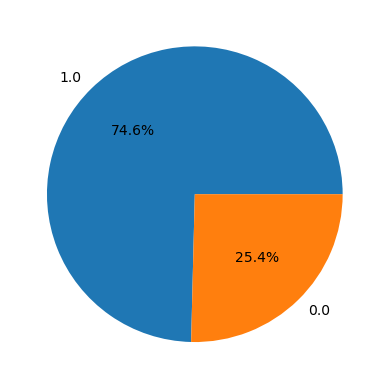

In [18]:
x = df['class'].value_counts()
plt.pie(x.values, 
        labels = x.index,
        autopct = '%1.1f%%')
plt.show()


In [22]:
features = df.drop('class', axis=1)
target = df['class']

X_train, X_val,Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.2,
                                      random_state=10)

ros = RandomOverSampler(sampling_strategy=1.0,
                        random_state=0)
X, Y = ros.fit_resample(X_train, Y_train)
X.shape, Y.value_counts()

((302, 286),
 class
 1.0    151
 0.0    151
 Name: count, dtype: int64)

In [24]:
df.describe()

,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_26,tqwt_kurtosisValue_dec_25,...,RPDE,DFA,PPE,gender,class
count,252.000000,252.000000,252.000000,252.000000,252.000000,...,252.000000,252.000000,252.000000,252.000000,252.000000
mean,14.799230,18.587888,26.237251,15.766942,6.782668,...,0.489058,0.700414,0.746284,0.515873,0.746032
std,12.378443,20.057960,35.525687,38.488742,28.317890,...,0.127195,0.066284,0.119996,0.500743,0.436146
min,2.330300,1.867967,1.526233,1.509067,1.521167,...,0.193853,0.555967,0.314347,0.000000,0.000000
25%,4.897958,4.436750,2.820458,1.697250,1.666933,...,0.393635,0.651182,0.691873,0.000000,0.000000
50%,9.492500,9.489333,8.644883,1.958467,1.838900,...,0.483117,0.699407,0.802037,1.000000,1.000000
75%,23.127600,26.345942,38.554292,3.686442,2.304192,...,0.575137,0.752511,0.823919,1.000000,1.000000
max,56.747467,107.571533,187.323300,222.247233,279.820933,...,0.826477,0.851113,0.869927,1.000000,1.000000


ValueError: Found input variables with inconsistent numbers of samples: [302, 252]